IMPORT LIBRARIES

In [39]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [40]:
# Load dataset
dataset = pd.read_csv('Oilwell.csv')
X = dataset.iloc[:, [5,8]].values
y = dataset.iloc[:, 1].values


In [41]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
print(X_test)
print(y_test)

[[ 76 124]
 [ 63 189]
 [ 75 113]
 ...
 [ 67 177]
 [ 73 111]
 [ 78 126]]
[13 29  9 37 13 21  8 13 24 10 28 24 14  8  9 15 13 20 13 14  8 11 14 13
 32 18 14 32  9 15 13 21 21 10 17 14  6  8  9 19 13  9 16 44  8 21  6 16
 22 37 13 14 18 14  7 10  8 10 16 38  9  6 16 32 17 10 21 27 22 10 22 20
 16 46 13 14  4 37 30  5 13 18 11 11 26 12 12 10 17 19 13 10 13 14 43 21
 12 22 14 16 14 22 18 17  8 29  7 38 16  7 22 10 15 12 12 20 10  7 30  9
 14  8 13 20 10 26 14 16 16 14 24 28 11 13 14 14 40 30  9 47 15  5 13 10
 22 13 11  3 13 20  7 29 11 15 15 30 21 12 41 15 15 22 11 12 14  7 16 14
 26 14 15 13 37 14 12  7 46  8  7 17 20  7 34 13 35 16 31 28 22 24  9 13
 12 22 30 28  2 14 28 47 14 10 14 22 14 11 13  9 14 11 20 22 36  8 11  6
 17 24 17  8 30 43  8 26 39  4 46  5 26 15 42 16 15 24 14 13 45 13 12 14
 44 16 14  3 22 26 12 15 30 16 10 20 16 16 39 29 26 27 30  7 17 38 24  7
 13 27 16 26  6 15 14 10 17  7 22 12  9 18 16 10  7 21 18 11 24 21 13 10
 15 11 10 13 14  2  7  8 34 14 15 19  5 43  5 10 12 

In [43]:
# Train the model
regressor = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
regressor.fit(X_train, y_train)
 
# Predict
y_pred = regressor.predict(X_test)


In [44]:
# Evaluate
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
 
print(f"Max Depth      : {regressor.max_depth}")
print(f"Tree Depth     : {regressor.get_depth()}")
print(f"Leaves         : {regressor.get_n_leaves()}")
print(f"MSE            : {mse:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"R² Score       : {r2:.4f}")


Max Depth      : 5
Tree Depth     : 5
Leaves         : 30
MSE            : 3.2521
RMSE           : 1.8033
R² Score       : 0.9654


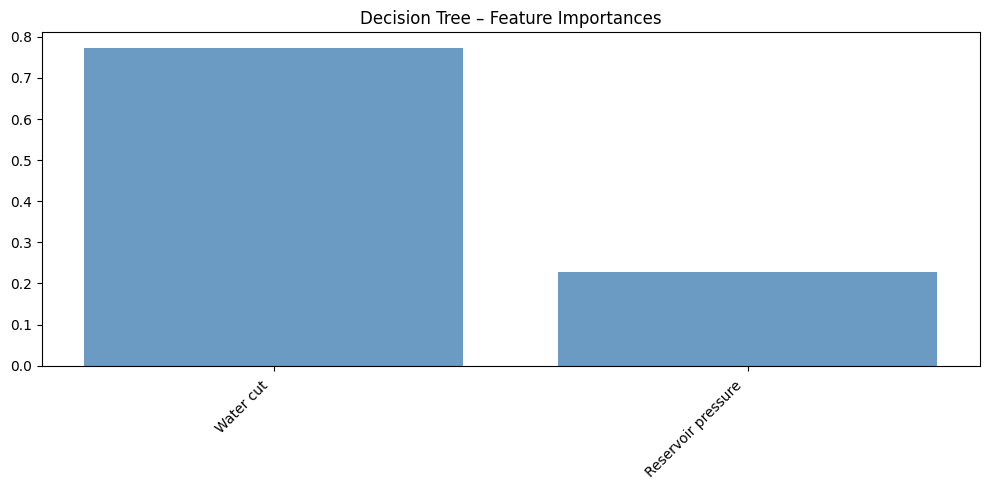

In [46]:
# Feature importances
feat_names = dataset.columns[[5, 8]].tolist()
importances = regressor.feature_importances_
indices = np.argsort(importances)[::-1]
 
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)),
        importances[indices], color='steelblue', alpha=0.8)
plt.xticks(range(len(importances)),
           [feat_names[i] for i in indices], rotation=45, ha='right')
plt.title("Decision Tree – Feature Importances")
plt.tight_layout()
plt.savefig("dt_feature_importance.png", dpi=150)
plt.show()

